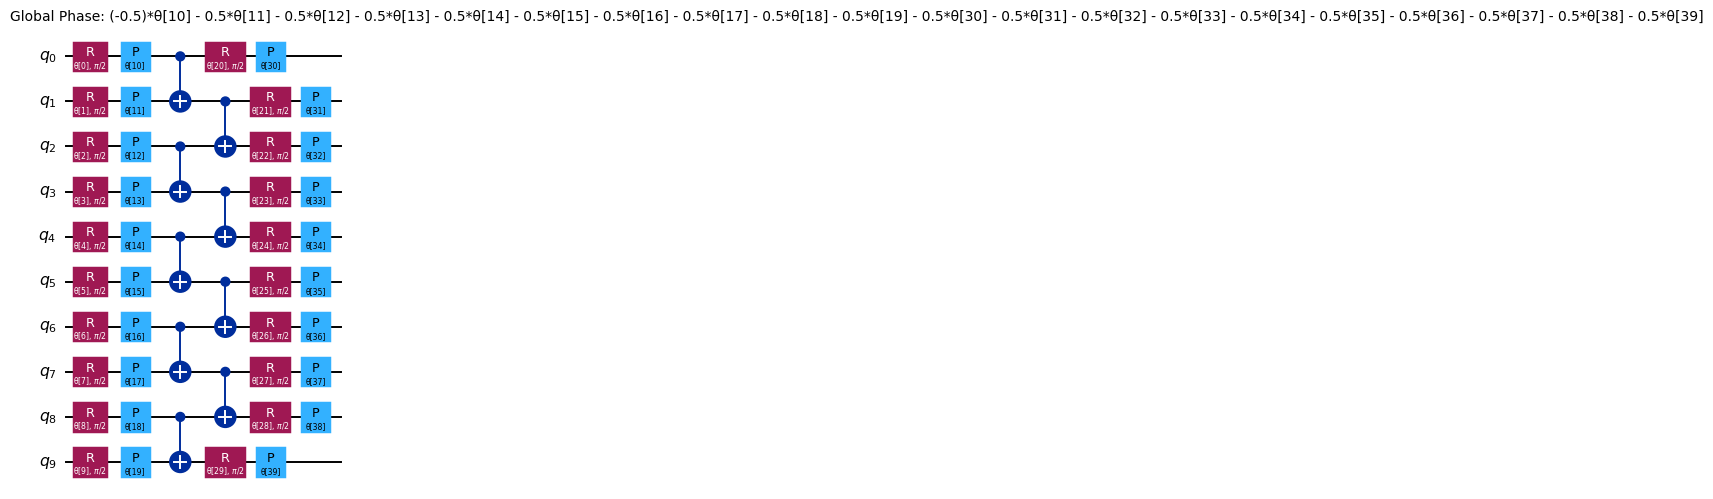

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from qiskit.circuit.library import efficient_su2, unitary_overlap
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, Batch, EstimatorV2 as Estimator

#Step 1: Map Input to Quantum Problem
n_qubits = 10
reps = 1

circuit = efficient_su2(n_qubits, entanglement="pairwise", reps=reps)

circuit.decompose().draw(output="mpl", scale=0.7)

In [2]:
# Z on the last qubit (index - 1) with coefficient 1.0
observable = SparsePauliOp.from_sparse_list(([("Z", [-1], 1.0)]), num_qubits=n_qubits)

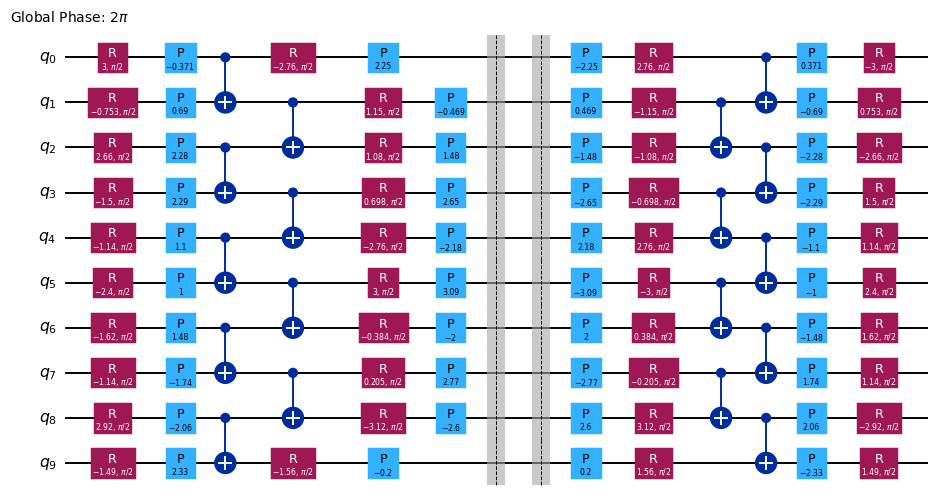

In [3]:
# Before mirroring the circuit, append a barrier instruction to it to 
# prevent the transpiler from merging the two parts of the circuit on 
# either side of the barrier and resulting in a transpiled 
# circuit without any gates.

# Generate random parameters
rng = np.random.default_rng(1234)
params = rng.uniform(-np.pi, np.pi, size=circuit.num_parameters)

# Assign parametres to the circuit
assigned_circuit = circuit.assign_parameters(params)

# Add a barrier to prevent circuit optimization of mirrored operators
assigned_circuit.barrier()

# Construct mirror circuit
mirror_circuit = unitary_overlap(assigned_circuit, assigned_circuit)

mirror_circuit.decompose().draw("mpl", scale=0.7)


In [5]:
# Step 2: Optimize
service = QiskitRuntimeService()
backend = service.backend("ibm_kingston")

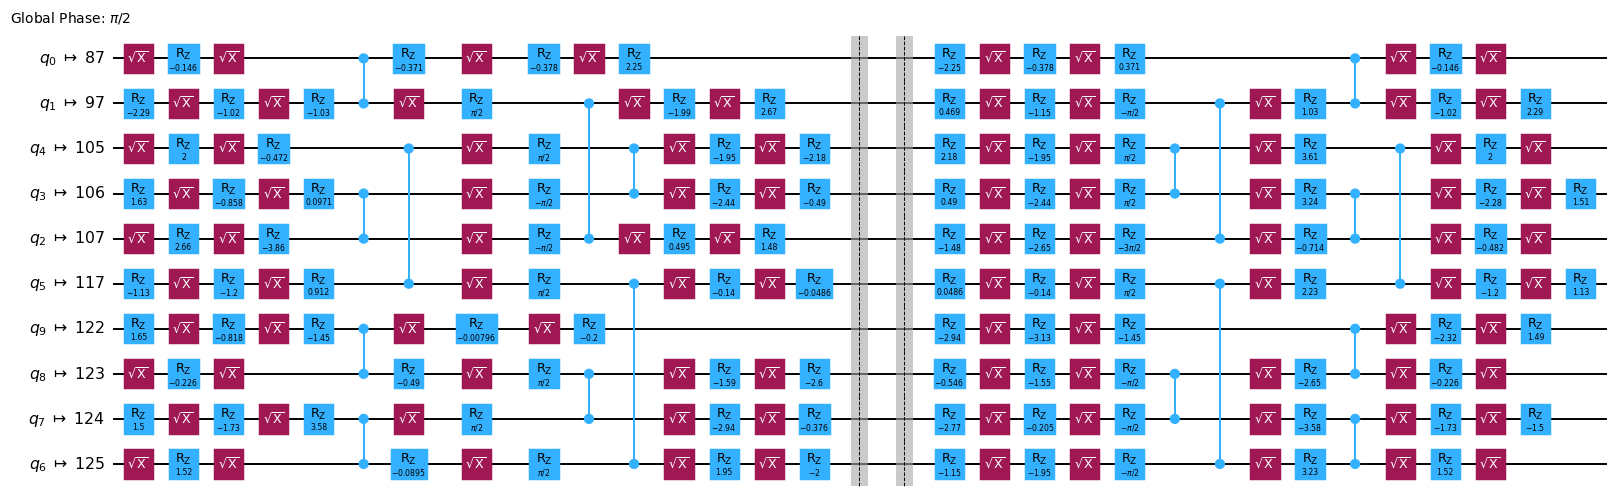

In [6]:
pass_manager = generate_preset_pass_manager(optimization_level=3, backend=backend, seed_transpiler=1234)

isa_circuit = pass_manager.run(mirror_circuit)

isa_circuit.draw("mpl", idle_wires=False, scale=0.7, fold=-1)

In [8]:
isa_observable = observable.apply_layout(isa_circuit.layout)

print("Original observable:")
print(observable)
print()
print("Observable with layout applied:")
print(isa_observable)

Original observable:
SparsePauliOp(['ZIIIIIIIII'],
              coeffs=[1.+0.j])

Observable with layout applied:
SparsePauliOp(['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII'],
              coeffs=[1.+0.j])


In [13]:
# Step 3: Execute Qiskit Primitives

pub = (isa_circuit, isa_observable)

jobs = []

with Batch(backend=backend) as batch:
    estimator = Estimator(mode=batch)
    estimator.options.environment.job_tags = [
        "TUT_CEM_SS"
    ] # add tag for this small scale job
    # Set number of shots
    estimator.options.default_shots = 100_000
    #Disable runtime compilation and error mitigation
    estimator.options.resilience_level = 0

    # Run job with no error mitigation
    job0 = estimator.run([pub])
    jobs.append(job0)

    # Add dynamical decoupling ( DD )
    estimator.options.dynamical_decoupling.enable = True
    estimator.options.dynamical_decoupling.sequence_type = "XpXm"
    job1 = estimator.run([pub])
    jobs.append(job1)

    # Add readout error mitigation ( DD + TREX )
    estimator.options.resilience.measure_mitigation = True
    job2 = estimator.run([pub])
    jobs.append(job2)

    # Add gate twirling ( DD + TREX + Gate Twirling )
    estimator.options.twirling.enable_gates = True
    estimator.options.twirling.num_randomizations = "auto"
    job3 = estimator.run([pub])
    jobs.append(job3)

    # Add zero-noise extrapolation ( DD + TREX + GAte Twirling + ZNE )
    estimator.options.resilience.zne_mitigation = True
    estimator.options.resilience.zne.noise_factors = (1, 3, 5)
    estimator.options.resilience.zne.extrapolator = ("exponential", "linear")
    job4 = estimator.run([pub])
    jobs.append(job4)


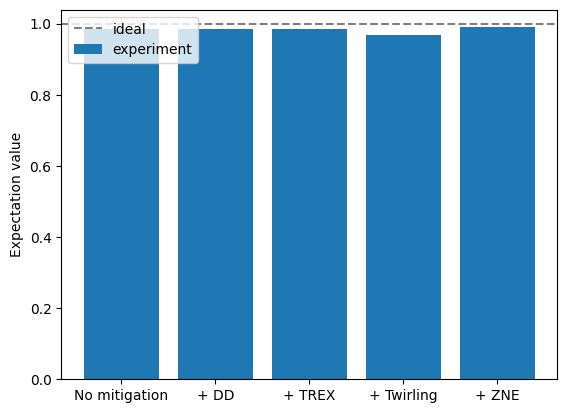

In [16]:
# Step 4: Post-Process + Output in Classical format

# Retrieve job results
results = [job.result() for job in jobs]

# Unpacking the PUB Results
pub_results = [result[0] for result in results]

# Unpack the expectatio nvalues and standard errors
expectation_vals = np.array([float(pub_result.data.evs) for pub_result in pub_results])

# standard_errors = np.array([float(pub_result.data.std) for pub_result in pub_results])

# Plot exp vals

fig, ax = plt.subplots()
labels = ["No mitigation", "+ DD", "+ TREX", "+ Twirling", "+ ZNE"]
ax.bar(
    range(len(labels)),
    expectation_vals,
    #yerr=standard_errors,
    label = "experiment",
)

ax.axhline(y=1.0, color="gray", linestyle="--", label="ideal")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_ylabel("Expectation value")
ax.legend(loc="upper left")

plt.show()